In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set_style('white')

In [7]:
# Carrega o conjunto de dados usando uma raw string para evitar problemas com as barras do Windows
dados_hoteis = pd.read_csv(r'Dados\hoteis.csv')


In [8]:
dados_hoteis.head()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458
2,4,15.504293,3,325.873550
3,4,4.173188,3,521.343284
4,4,9.443685,1,252.587087


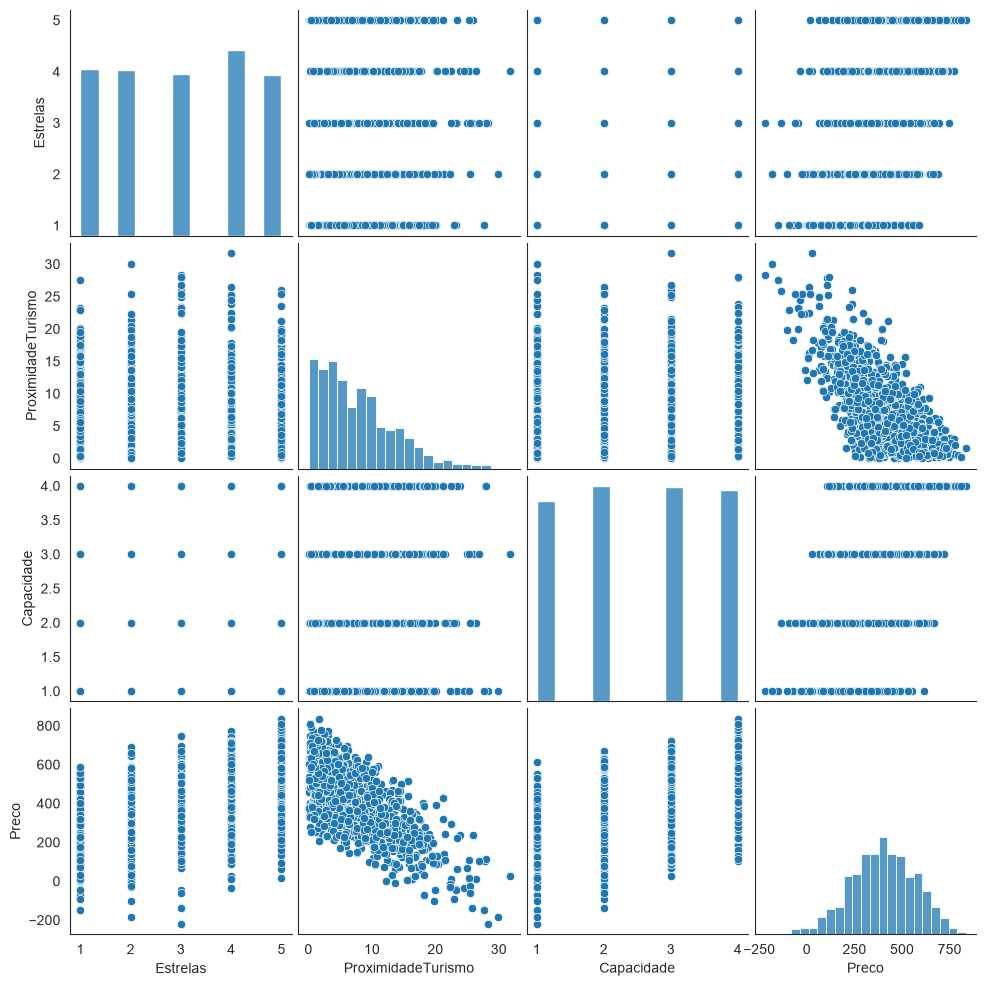

In [9]:
sns.pairplot(dados_hoteis)

In [10]:
x = dados_hoteis[['Estrelas', 'ProximidadeTurismo', 'Capacidade']]

In [11]:
y = dados_hoteis['Preco']

In [12]:
from sklearn.model_selection import train_test_split

In [15]:

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=230)

In [16]:
import statsmodels.api as sm

In [17]:
X_train_com_constante = sm.add_constant(X_train)

In [18]:
modelo_hoteis = sm.OLS(y_train, X_train_com_constante).fit()

In [19]:
print(modelo_hoteis.summary())

                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     2828.
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:01:07   Log-Likelihood:                -3689.2
No. Observations:                 700   AIC:                             7386.
Df Residuals:                     696   BIC:                             7405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                195.1576      6

### 📊 Análise Estatística do Modelo de Precificação de Hotéis

Abaixo está a interpretação detalhada das métricas obtidas no resumo do modelo:

#### 1. Qualidade do Ajuste ($R^2$)
* **R-squared ($R^2$) = 0.924**: Isto indica que as variáveis escolhidas conseguem explicar **92,4%** da variação dos preços dos quartos de hotéis. É um modelo com altíssimo poder explicativo e excelente precisão.

#### 2. Interpretação dos Coeficientes ($\beta$)
Os coeficientes nos dizem o impacto prático de cada variável no preço final do quarto:

* **Preço Base (Intercepto / `const`) = 195.15**: É o ponto de partida do modelo. Se todas as outras variáveis fossem zero, o valor base estimado seria de \$195.15.
* **Estrelas (`Estrelas`) = +50.50**: Cada estrela adicional na classificação do hotel aumenta o preço do quarto em, em média, \$50.50.
* **Proximidade do Turismo (`ProximidadeTurismo`) = -20.35**: Para cada unidade de distância que o hotel se afasta dos pontos turísticos, o preço do quarto cai \$20.35. Isso valida a hipótese de que hotéis mais centralizados são mais caros.
* **Capacidade (`Capacidade`) = +81.52**: Cada unidade a mais de capacidade (tamanho/acomodação do quarto) eleva o preço em \$81.52.


### 💡 Regra de Ouro: Identificando Variáveis em Ciência de Dados

Para estruturar qualquer modelo de Regressão Linear, é fundamental compreender o papel das variáveis no problema de negócios:

#### 1. Variável Alvo / Dependente ($y$)
* **O que é**: É o resultado final que o modelo tenta prever ou estimar.
* **Neste Projeto**: **`Preco`**. Nosso objetivo de negócio é descobrir o valor correto de um quarto com base em suas características.

#### 2. Variáveis Preditoras / Características / Independentes ($X$)
* **O que são**: São as pistas, atributos ou dados históricos que explicam ou causam impacto no resultado final.
* **Neste Projeto**: **`estrelas`**, **`ProximidadeTurismo`** e **`Capacidade`**. São os fatores que determinam se o preço do quarto deve subir ou descer.
